# Trabajo Práctico Nº2

## Taller de Programación

### Maestría en Economía Aplicada

Universidad de Buenos Aires

**Grupo 2**

- Andrea Chasi
- Santiago Soler
- Pablo Ortiz

Carga de Datos

In [89]:
from google.colab import files
uploaded = files.upload()

Saving usu_individual_T424.xlsx to usu_individual_T424 (1).xlsx
Saving usu_individual_T425.xlsx to usu_individual_T425 (1).xlsx


Parte 1: Creación de Variables y estadística descriptiva

Lectura y selección de Variables

In [90]:
import pandas as pd
import numpy as np

variables = [
    'CODUSU','ANO4','TRIMESTRE','NRO_HOGAR','COMPONENTE',
    'PONDERA','AGLOMERADO','CH03','CH04','CH06','CH07','CH08',
    'CH12','CH13','CH14',
    'NIVEL_ED','ESTADO','CAT_OCUP','PP04C','PP04D_COD',
    'PP07H','PP07I','PP07J','PP07K','PP08D1','PP08F1',
    'PP3E_TOT','PP3F_TOT',
    'P21','P47T'
]

eph24 = pd.read_excel("usu_individual_T424.xlsx")
eph25 = pd.read_excel("usu_individual_T425.xlsx")

eph24_sel = eph24[variables].copy()
eph25_sel = eph25[variables].copy()

Filtrar respondieron/ocupados

In [91]:
for df in [eph24_sel, eph25_sel]:
    df["P21"] = df["P21"].replace(-9, np.nan)
    df["P47T"] = df["P47T"].replace(-9, np.nan)

respondieron24 = eph24_sel[eph24_sel["ESTADO"] != 0].copy()
respondieron25 = eph25_sel[eph25_sel["ESTADO"] != 0].copy()

ocupados24 = respondieron24[respondieron24["ESTADO"] == 1].copy()
ocupados25 = respondieron25[respondieron25["ESTADO"] == 1].copy()

print("Ocupados 2024:", ocupados24.shape)
print("Ocupados 2025:", ocupados25.shape)

Ocupados 2024: (21132, 30)
Ocupados 2025: (19698, 30)


Variables del TP1

In [92]:
for df in [ocupados24, ocupados25]:
    df["mujer"] = (df["CH04"] == 2).astype(int)
    df["casado"] = df["CH07"].isin([1, 2]).astype(int)
    df["universitario"] = (df["NIVEL_ED"] >= 6).astype(int)
    df["asalariado"] = (df["CAT_OCUP"] == 3).astype(int)
    df["informal"] = np.where((df["CAT_OCUP"] == 3) & (df["PP07H"] == 2), 1, 0)
    df["condicion_laboral"] = np.where(df["informal"] == 1, "Informal", "Formal")

Variables nuevas

In [93]:
anios_nivel = {1: 0, 2: 7, 3: 9, 4: 12, 5: 12, 6: 15, 7: 17, 8: 19, 9: 0}

def calcular_educ(row):
    nivel, finalizo, ultimo_anio = row["CH12"], row["CH13"], row["CH14"]
    if pd.isna(nivel) or nivel not in anios_nivel:
        return np.nan
    if finalizo == 1:
        return anios_nivel[nivel]
    base = anios_nivel.get(nivel - 1, 0)
    if pd.isna(ultimo_anio) or ultimo_anio in [98, 99]:
        return base
    return base + ultimo_anio

for df in [ocupados24, ocupados25]:
    # a) edad2
    df["edad2"] = df["CH06"] ** 2

    # b) educ
    df["educ"] = df.apply(calcular_educ, axis=1)

    # c) horastrab (solo jefe de hogar, CH03 == 1)
    df["jefe_hogar"] = (df["CH03"] == 1).astype(int)
    df["horastrab"] = np.where(
        df["jefe_hogar"] == 1,
        df["PP3E_TOT"].fillna(0) + df["PP3F_TOT"].fillna(0),
        np.nan
    )

    # d) nhogar
    df["nhogar"] = df.groupby(["CODUSU", "NRO_HOGAR"])["COMPONENTE"].transform("count")

print(ocupados24[["edad2","educ","horastrab","nhogar"]].describe())

              edad2          educ     horastrab        nhogar
count  21132.000000  21103.000000  10390.000000  21132.000000
mean    1878.641823     12.905322     40.781328      2.021579
std     1154.248578      3.468660     57.600794      0.980144
min      121.000000      0.000000      0.000000      1.000000
25%      961.000000     12.000000     30.000000      1.000000
50%     1600.000000     12.000000     40.000000      2.000000
75%     2601.000000     15.000000     48.000000      2.000000
max     8464.000000     24.000000   1998.000000      7.000000


Revisar horas trab

In [94]:
for df in [ocupados24, ocupados25]:
    for col in ["PP3E_TOT", "PP3F_TOT"]:
        df[col] = df[col].replace([999, 9999], np.nan)

    df["horastrab"] = np.where(
        df["jefe_hogar"] == 1,
        df["PP3E_TOT"].fillna(0) + df["PP3F_TOT"].fillna(0),
        np.nan
    )

print(ocupados24["horastrab"].describe())

count    10390.000000
mean        38.762175
std         16.874102
min          0.000000
25%         30.000000
50%         40.000000
75%         48.000000
max        154.000000
Name: horastrab, dtype: float64


Revisar educ

In [95]:
ocupados24[ocupados24["educ"] > 19][["CH12","CH13","CH14","educ"]].head(10)

,CH12,CH13,CH14,educ
1143,7,2,5.0,20.0
1167,7,2,5.0,20.0
1884,7,2,9.0,24.0
2658,7,2,5.0,20.0
2671,7,2,5.0,20.0
3125,7,2,5.0,20.0
3156,7,2,5.0,20.0
3357,8,2,3.0,20.0
3404,7,2,6.0,21.0
3506,7,2,5.0,20.0


Corrigiendo educ

In [96]:

anios_nivel = {1: 0, 2: 7, 3: 9, 4: 12, 5: 12, 6: 15, 7: 17, 8: 19, 9: 0}
anios_entrada = {1: 0, 2: 0, 3: 0, 4: 7, 5: 9, 6: 12, 7: 12, 8: 17, 9: 0}

def calcular_educ(row):
    nivel, finalizo, ultimo_anio = row["CH12"], row["CH13"], row["CH14"]
    if pd.isna(nivel) or nivel not in anios_nivel:
        return np.nan
    if finalizo == 1:
        return anios_nivel[nivel]
    base = anios_entrada.get(nivel, 0)
    if pd.isna(ultimo_anio) or ultimo_anio in [98, 99]:
        return base
    return base + ultimo_anio

for df in [ocupados24, ocupados25]:
    df["educ"] = df.apply(calcular_educ, axis=1)

print(ocupados24["educ"].describe())
ocupados24[ocupados24["educ"] > 19][["CH12","CH13","CH14","educ"]].head(10)

count    21103.000000
mean        12.233379
std          3.392301
min          0.000000
25%         11.000000
50%         12.000000
75%         15.000000
max         22.000000
Name: educ, dtype: float64


,CH12,CH13,CH14,educ
1884,7,2,9.0,21.0
3357,8,2,3.0,20.0
5373,8,2,3.0,20.0
19369,8,2,4.0,21.0
22479,8,2,3.0,20.0
22816,8,2,4.0,21.0
25194,8,2,5.0,22.0
31836,8,2,4.0,21.0
34751,8,2,3.0,20.0
40146,8,2,3.0,20.0


## Corrección y cierre de la Parte I

In [97]:
# ============================================================
# CORRECCIÓN Y CIERRE DE LA PARTE I
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Limpiar horas trabajadas en las bases seleccionadas
# ------------------------------------------------------------

for df in [eph24_sel, eph25_sel]:
    for col in ["PP3E_TOT", "PP3F_TOT"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([999, 9999, -9], np.nan)

# ------------------------------------------------------------
# 2. Calcular tamaño real del hogar sobre la base completa
# ------------------------------------------------------------

for df in [eph24_sel, eph25_sel]:
    df["nhogar"] = (
        df.groupby(["CODUSU", "NRO_HOGAR"])["COMPONENTE"]
          .transform("count")
    )

# ------------------------------------------------------------
# 3. Reconstruir bases de ocupados
# ------------------------------------------------------------

respondieron24 = eph24_sel[eph24_sel["ESTADO"] != 0].copy()
respondieron25 = eph25_sel[eph25_sel["ESTADO"] != 0].copy()

ocupados24 = respondieron24[respondieron24["ESTADO"] == 1].copy()
ocupados25 = respondieron25[respondieron25["ESTADO"] == 1].copy()

# ------------------------------------------------------------
# 4. Función para años de educación
# ------------------------------------------------------------

anios_completos = {
    1: 0,   # Jardín / preescolar
    2: 7,   # Primario
    3: 9,   # EGB
    4: 12,  # Secundario
    5: 12,  # Polimodal
    6: 15,  # Superior universitario
    7: 17,  # Universitario
    8: 19   # Posgrado
}

anios_entrada = {
    1: 0,
    2: 0,
    3: 0,
    4: 7,
    5: 9,
    6: 12,
    7: 12,
    8: 17
}

def calcular_educ(row):
    nivel = row["CH12"]
    finalizo = row["CH13"]
    ultimo_anio = row["CH14"]

    if pd.isna(nivel) or nivel not in anios_completos:
        return np.nan

    if finalizo == 1:
        return anios_completos[nivel]

    if finalizo == 2:
        base = anios_entrada[nivel]

        if pd.isna(ultimo_anio) or ultimo_anio in [98, 99]:
            return base

        return base + ultimo_anio

    return np.nan

# ------------------------------------------------------------
# 5. Crear variables solicitadas
# ------------------------------------------------------------

for df in [ocupados24, ocupados25]:

    # Edad y edad al cuadrado
    df["edad"] = pd.to_numeric(df["CH06"], errors="coerce")
    df["edad2"] = df["edad"] ** 2

    # Años de educación
    df["educ"] = df.apply(calcular_educ, axis=1)
    df.loc[~df["educ"].between(0, 25), "educ"] = np.nan

    # Jefe/a del hogar
    df["jefe_hogar"] = (df["CH03"] == 1).astype(int)

    # Horas trabajadas para jefe/a del hogar
    df["horastrab"] = np.where(
        df["jefe_hogar"] == 1,
        df["PP3E_TOT"].fillna(0) + df["PP3F_TOT"].fillna(0),
        np.nan
    )

    df.loc[~df["horastrab"].between(0, 168), "horastrab"] = np.nan

    # Variables binarias del TP1
    df["mujer"] = (df["CH04"] == 2).astype(int)
    df["casado"] = df["CH07"].isin([1, 2]).astype(int)
    df["universitario"] = (df["NIVEL_ED"] >= 6).astype(int)
    df["asalariado"] = (df["CAT_OCUP"] == 3).astype(int)

    # Formal wage employee
    df["formal"] = (
        (df["CAT_OCUP"] == 3) &
        (df["PP07H"] == 1)
    ).astype(int)

    # Upper-tier informal wage employee
    df["informal"] = (
        (df["CAT_OCUP"] == 3) &
        (df["PP07H"] == 2) &
        (df["PP04C"].isin([6, 7, 8, 9, 10, 11, 12]))
    ).astype(int)

print("Variables TP2 creadas correctamente.")

Variables TP2 creadas correctamente.


In [98]:
variables_tp2 = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21",
    "PP04C",
    "formal",
    "informal"
]

print("DESCRIPTIVOS 2024")
display(ocupados24[variables_tp2].describe().T.round(2))

print("\nDESCRIPTIVOS 2025")
display(ocupados25[variables_tp2].describe().T.round(2))

print("\nFORMAL E INFORMAL 2024")
display(ocupados24[["formal", "informal"]].sum())

print("\nFORMAL E INFORMAL 2025")
display(ocupados25[["formal", "informal"]].sum())

DESCRIPTIVOS 2024


,count,mean,std,min,25%,50%,75%,max
edad,21132.0,41.31,13.13,11.0,31.0,40.0,51.0,92.0
edad2,21132.0,1878.64,1154.25,121.0,961.0,1600.0,2601.0,8464.0
educ,21093.0,12.24,3.38,0.0,11.0,12.0,15.0,22.0
horastrab,10390.0,38.76,16.87,0.0,30.0,40.0,48.0,154.0
nhogar,21132.0,3.54,1.79,1.0,2.0,3.0,4.0,19.0
P21,16857.0,629777.42,613955.51,0.0,250000.0,500000.0,800000.0,15000000.0
PP04C,21132.0,17.05,31.63,0.0,1.0,6.0,10.0,99.0
formal,21132.0,0.46,0.50,0.0,0.0,0.0,1.0,1.0
informal,21132.0,0.07,0.26,0.0,0.0,0.0,0.0,1.0



DESCRIPTIVOS 2025


,count,mean,std,min,25%,50%,75%,max
edad,19698.0,41.86,13.29,12.0,31.0,41.0,52.0,100.0
edad2,19698.0,1928.69,1179.41,144.0,961.0,1681.0,2704.0,10000.0
educ,19657.0,12.17,3.39,0.0,10.0,12.0,15.0,21.0
horastrab,9608.0,39.00,17.19,0.0,30.0,40.0,48.0,140.0
nhogar,19698.0,3.52,1.75,1.0,2.0,3.0,4.0,16.0
P21,15784.0,917209.06,909163.39,0.0,400000.0,800000.0,1200000.0,30000000.0
PP04C,19698.0,17.69,32.56,0.0,1.0,6.0,10.0,99.0
formal,19698.0,0.45,0.50,0.0,0.0,0.0,1.0,1.0
informal,19698.0,0.07,0.25,0.0,0.0,0.0,0.0,1.0



FORMAL E INFORMAL 2024


,0
formal,9727
informal,1578



FORMAL E INFORMAL 2025


,0
formal,8815
informal,1377


In [99]:
# ==========================================
# MATRIZ DE CORRELACIONES
# ==========================================

variables_pca = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21",
    "PP04C"
]

print("Correlaciones 2024")
corr24 = ocupados24[variables_pca].corr()
display(corr24.round(3))

print("\nCorrelaciones 2025")
corr25 = ocupados25[variables_pca].corr()
display(corr25.round(3))

Correlaciones 2024


,edad,edad2,educ,horastrab,nhogar,P21,PP04C
edad,1.000,0.985,-0.062,-0.107,-0.173,0.120,-0.058
edad2,0.985,1.000,-0.074,-0.121,-0.177,0.096,-0.058
educ,-0.062,-0.074,1.000,0.041,-0.196,0.300,0.045
horastrab,-0.107,-0.121,0.041,1.000,0.033,0.278,0.047
nhogar,-0.173,-0.177,-0.196,0.033,1.000,-0.147,0.048
P21,0.120,0.096,0.300,0.278,-0.147,1.000,0.050
PP04C,-0.058,-0.058,0.045,0.047,0.048,0.050,1.000



Correlaciones 2025


,edad,edad2,educ,horastrab,nhogar,P21,PP04C
edad,1.000,0.985,-0.085,-0.107,-0.182,0.116,-0.063
edad2,0.985,1.000,-0.102,-0.122,-0.185,0.092,-0.062
educ,-0.085,-0.102,1.000,0.032,-0.192,0.287,0.037
horastrab,-0.107,-0.122,0.032,1.000,0.049,0.226,0.065
nhogar,-0.182,-0.185,-0.192,0.049,1.000,-0.141,0.050
P21,0.116,0.092,0.287,0.226,-0.141,1.000,0.039
PP04C,-0.063,-0.062,0.037,0.065,0.050,0.039,1.000


# Parte II.A - Análisis de Componentes Principales (PCA)

In [100]:
from sklearn.preprocessing import StandardScaler

variables_pca = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21",
    "PP04C"
]

# Eliminar NA
pca24 = ocupados24[variables_pca].dropna().copy()
pca25 = ocupados25[variables_pca].dropna().copy()

print("Observaciones PCA 2024:", pca24.shape)
print("Observaciones PCA 2025:", pca25.shape)

# Estandarizar
scaler24 = StandardScaler()
X24 = scaler24.fit_transform(pca24)

scaler25 = StandardScaler()
X25 = scaler25.fit_transform(pca25)

print("Media 2024:", X24.mean(axis=0).round(5))
print("Std 2024:", X24.std(axis=0).round(5))

print("Media 2025:", X25.mean(axis=0).round(5))
print("Std 2025:", X25.std(axis=0).round(5))

Observaciones PCA 2024: (8584, 7)
Observaciones PCA 2025: (7987, 7)
Media 2024: [-0.  0.  0. -0.  0.  0. -0.]
Std 2024: [1. 1. 1. 1. 1. 1. 1.]
Media 2025: [-0. -0.  0. -0.  0.  0. -0.]
Std 2025: [1. 1. 1. 1. 1. 1. 1.]


In [101]:
from sklearn.decomposition import PCA

pca_model24 = PCA()
scores24 = pca_model24.fit_transform(X24)

pca_model25 = PCA()
scores25 = pca_model25.fit_transform(X25)

In [102]:
import pandas as pd

var24 = pd.DataFrame({
    "Componente": range(1, len(variables_pca)+1),
    "Varianza": pca_model24.explained_variance_ratio_,
    "Acumulada": pca_model24.explained_variance_ratio_.cumsum()
})

var25 = pd.DataFrame({
    "Componente": range(1, len(variables_pca)+1),
    "Varianza": pca_model25.explained_variance_ratio_,
    "Acumulada": pca_model25.explained_variance_ratio_.cumsum()
})

print("2024")
display(var24.round(4))

print("2025")
display(var25.round(4))

2024


,Componente,Varianza,Acumulada
0,1,0.2976,0.2976
1,2,0.2032,0.5008
2,3,0.1635,0.6642
3,4,0.1379,0.8021
4,5,0.1141,0.9162
5,6,0.0822,0.9984
6,7,0.0016,1.0000


2025


,Componente,Varianza,Acumulada
0,1,0.2995,0.2995
1,2,0.1964,0.4959
2,3,0.1644,0.6603
3,4,0.1365,0.7968
4,5,0.1163,0.9132
5,6,0.0852,0.9984
6,7,0.0016,1.0000


In [103]:
loadings24 = pd.DataFrame(
    pca_model24.components_.T,
    index=variables_pca,
    columns=[f"PC{i}" for i in range(1, len(variables_pca)+1)]
)

loadings25 = pd.DataFrame(
    pca_model25.components_.T,
    index=variables_pca,
    columns=[f"PC{i}" for i in range(1, len(variables_pca)+1)]
)

print("Loadings 2024")
display(loadings24.round(3))

print("Loadings 2025")
display(loadings25.round(3))

Loadings 2024


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
edad,0.661,0.232,0.050,0.009,-0.003,-0.087,-0.706
edad2,0.663,0.229,0.020,0.017,-0.029,-0.080,0.707
educ,-0.232,0.520,-0.310,0.202,0.443,-0.585,0.005
horastrab,-0.201,0.337,0.512,-0.392,-0.510,-0.412,0.007
nhogar,0.067,-0.300,0.646,-0.127,0.664,-0.176,0.026
P21,-0.142,0.641,0.201,-0.145,0.257,0.664,0.008
PP04C,-0.070,0.087,0.426,0.876,-0.191,0.037,0.001


Loadings 2025


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
edad,0.659,0.235,0.035,0.002,0.006,0.106,-0.706
edad2,0.661,0.229,0.006,0.009,-0.019,0.094,0.708
educ,-0.272,0.525,-0.254,0.182,0.374,0.642,0.009
horastrab,-0.173,0.288,0.552,-0.415,-0.542,0.343,0.009
nhogar,0.073,-0.318,0.613,-0.163,0.675,0.186,0.026
P21,-0.133,0.652,0.180,-0.167,0.294,-0.641,0.007
PP04C,-0.046,0.091,0.471,0.860,-0.156,-0.060,0.003


# Parte II.B.4 - Clustering mediante K-Means

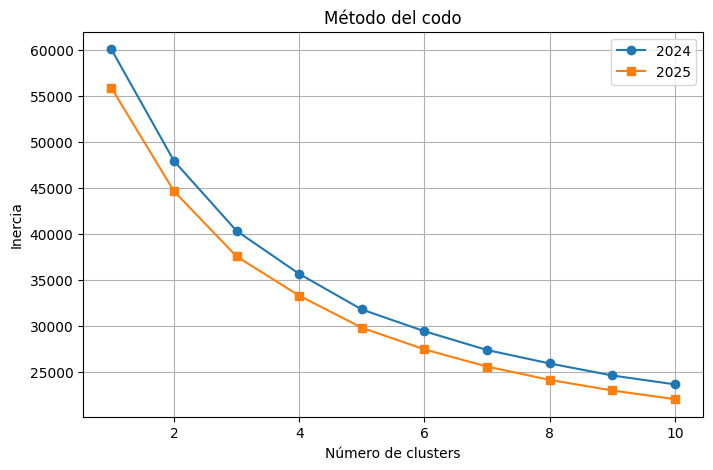

In [104]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia24 = []
inercia25 = []

k_values = range(1, 11)

for k in k_values:
    km24 = KMeans(n_clusters=k, random_state=123, n_init=10)
    km24.fit(X24)
    inercia24.append(km24.inertia_)

    km25 = KMeans(n_clusters=k, random_state=123, n_init=10)
    km25.fit(X25)
    inercia25.append(km25.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inercia24, marker="o", label="2024")
plt.plot(k_values, inercia25, marker="s", label="2025")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.legend()
plt.grid(True)
plt.show()

In [105]:
k = 3

kmeans24 = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=20
)

cluster24 = kmeans24.fit_predict(X24)

kmeans25 = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=20
)

cluster25 = kmeans25.fit_predict(X25)

pca24["cluster"] = cluster24
pca25["cluster"] = cluster25

print("2024")
print(pca24.cluster.value_counts())

print("\n2025")
print(pca25.cluster.value_counts())

2024
cluster
2    4739
0    3120
1     725
Name: count, dtype: int64

2025
cluster
1    4319
0    2953
2     715
Name: count, dtype: int64


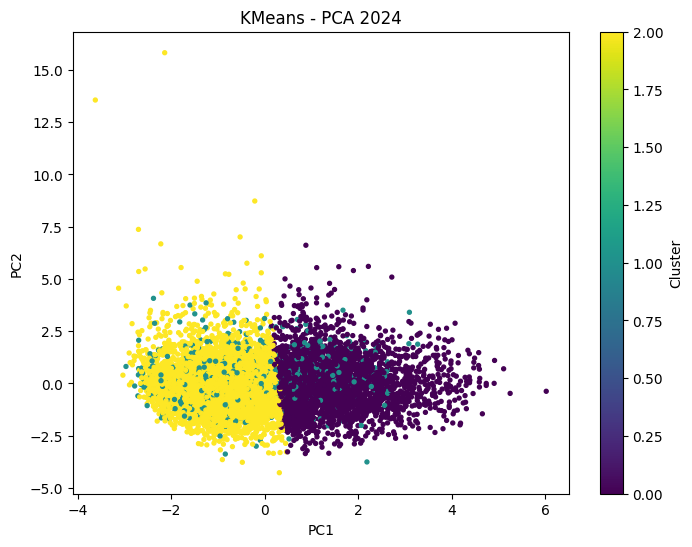

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    scores24[:,0],
    scores24[:,1],
    c=cluster24,
    cmap="viridis",
    s=8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans - PCA 2024")
plt.colorbar(label="Cluster")
plt.show()

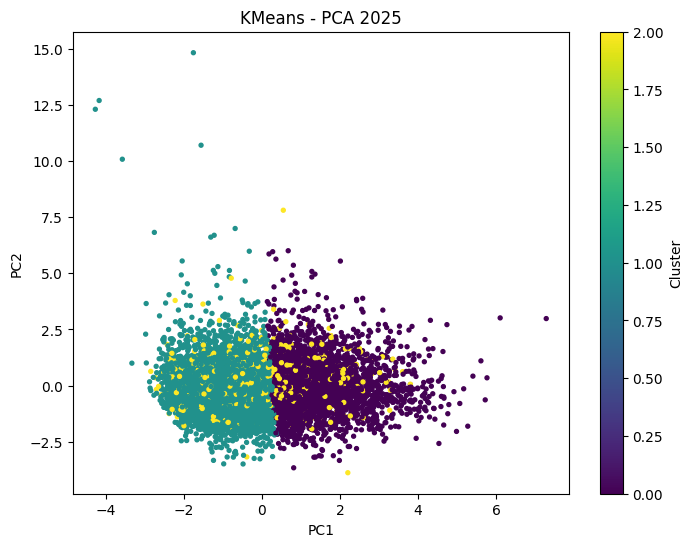

In [107]:
plt.figure(figsize=(8,6))

plt.scatter(
    scores25[:,0],
    scores25[:,1],
    c=cluster25,
    cmap="viridis",
    s=8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans - PCA 2025")
plt.colorbar(label="Cluster")
plt.show()

# Parte II.B.5 - Clustering Jerárquico

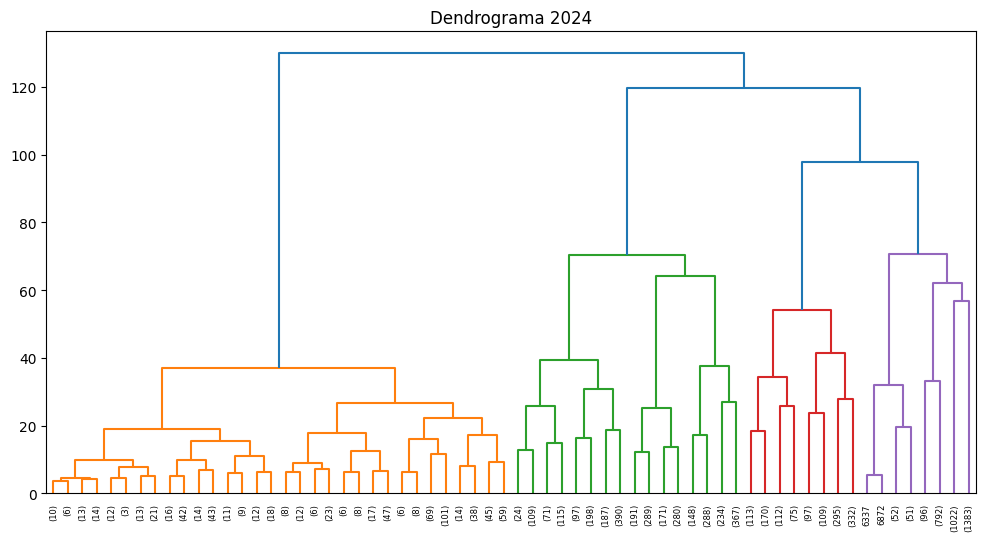

In [108]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X24, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrograma 2024")
plt.show()

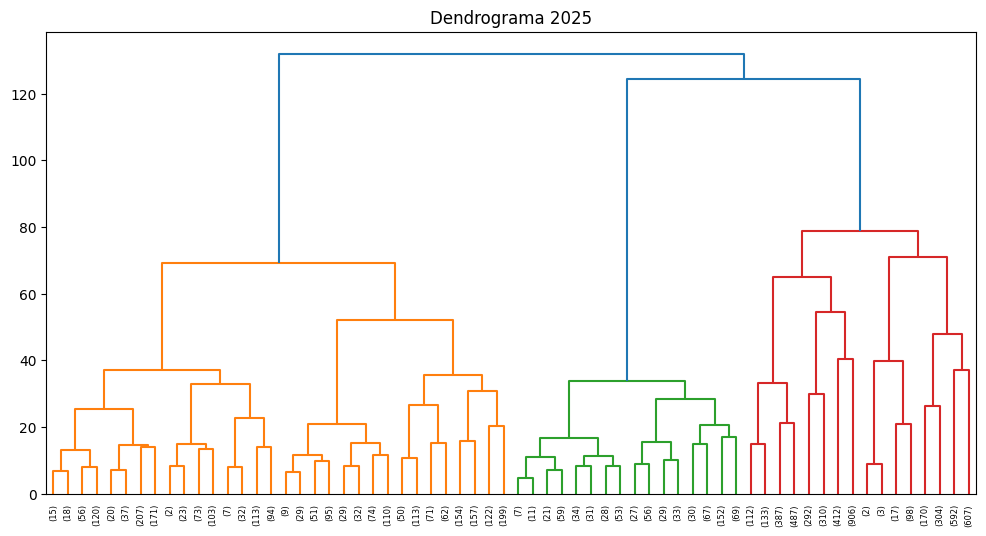

In [109]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X25, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrograma 2025")
plt.show()

In [110]:
print("===== Perfil de los clusters 2024 =====")

display(
    pca24.groupby("cluster")[variables_pca]
    .mean()
    .round(2)
)

print("\n===== Perfil de los clusters 2025 =====")

display(
    pca25.groupby("cluster")[variables_pca]
    .mean()
    .round(2)
)

===== Perfil de los clusters 2024 =====


,edad,edad2,educ,horastrab,nhogar,P21,PP04C
cluster,,,,,,,
0,57.13,3314.80,11.08,33.58,2.97,614832.08,4.45
1,44.26,2092.97,12.22,40.35,3.30,729183.20,99.00
2,37.18,1438.41,13.05,41.27,2.92,806284.32,6.02



===== Perfil de los clusters 2025 =====


,edad,edad2,educ,horastrab,nhogar,P21,PP04C
cluster,,,,,,,
0,57.61,3371.51,10.83,35.01,3.01,900678.88,4.41
1,37.73,1480.41,13.15,41.11,2.87,1156482.01,5.80
2,45.68,2212.07,12.09,41.38,3.29,1053707.69,99.00


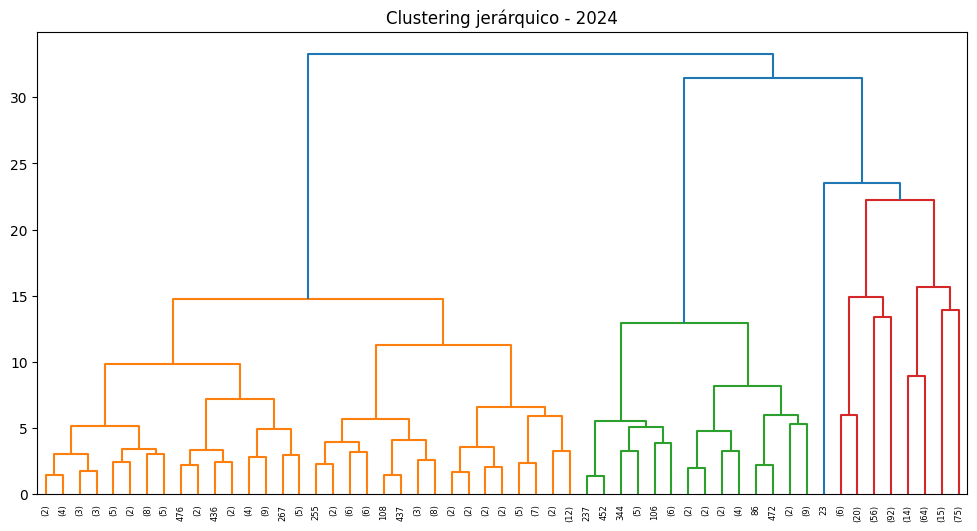

In [111]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

muestra24 = pca24.sample(500, random_state=123)

X_muestra24 = StandardScaler().fit_transform(muestra24[variables_pca])

Z = linkage(X_muestra24, method="ward")

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    truncate_mode="level",
    p=5
)

plt.title("Clustering jerárquico - 2024")
plt.show()

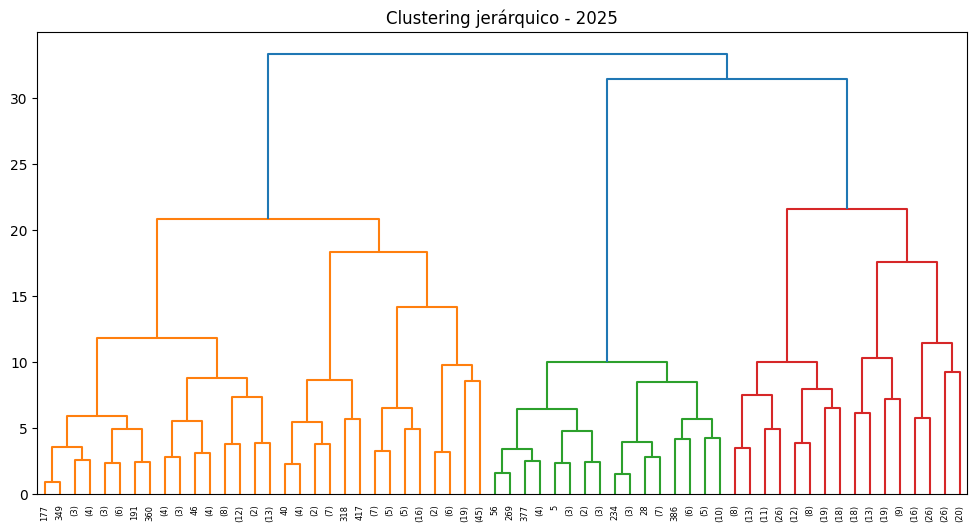

In [112]:
muestra25 = pca25.sample(500, random_state=123)

X_muestra25 = StandardScaler().fit_transform(muestra25[variables_pca])

Z = linkage(X_muestra25, method="ward")

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    truncate_mode="level",
    p=5
)

plt.title("Clustering jerárquico - 2025")
plt.show()

In [113]:
# ==========================================================
# LIMPIEZA DE PP04C
# ==========================================================

for df in [ocupados24, ocupados25]:

    # Convertir a numérico
    df["PP04C"] = pd.to_numeric(df["PP04C"], errors="coerce")

    # Códigos especiales de la EPH
    df["PP04C"] = df["PP04C"].replace(
        [98, 99, -9],
        np.nan
    )

print("PP04C limpiada correctamente.")

PP04C limpiada correctamente.


In [114]:
print("2024")
print(ocupados24["PP04C"].value_counts(dropna=False).sort_index())

print("\n2025")
print(ocupados25["PP04C"].value_counts(dropna=False).sort_index())

2024
PP04C
0.0     1409
1.0     3965
2.0     1808
3.0     1158
4.0      684
5.0      663
6.0     1516
7.0     1548
8.0     1444
9.0     1589
10.0     885
11.0     779
12.0     975
NaN     2709
Name: count, dtype: int64

2025
PP04C
0.0     1342
1.0     4012
2.0     1756
3.0      980
4.0      654
5.0      569
6.0     1426
7.0     1311
8.0     1240
9.0     1409
10.0     780
11.0     678
12.0     847
NaN     2694
Name: count, dtype: int64


In [115]:
variables_pca = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21",
    "PP04C"
]

pca24 = ocupados24[variables_pca].dropna().copy()
pca25 = ocupados25[variables_pca].dropna().copy()

print(pca24.shape)
print(pca25.shape)

(7858, 7)
(7271, 7)


In [116]:
from sklearn.preprocessing import StandardScaler

scaler24 = StandardScaler()
X24 = scaler24.fit_transform(pca24)

scaler25 = StandardScaler()
X25 = scaler25.fit_transform(pca25)

In [117]:
from sklearn.decomposition import PCA

pca_model24 = PCA()
scores24 = pca_model24.fit_transform(X24)

pca_model25 = PCA()
scores25 = pca_model25.fit_transform(X25)

In [118]:
from sklearn.cluster import KMeans

k = 3

kmeans24 = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=20
)

cluster24 = kmeans24.fit_predict(X24)

kmeans25 = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=20
)

cluster25 = kmeans25.fit_predict(X25)

pca24["cluster"] = cluster24
pca25["cluster"] = cluster25

In [119]:
# ==========================================================
# Winsorización de P21 (1% y 99%)
# ==========================================================

for df in [ocupados24, ocupados25]:

    p1 = df["P21"].quantile(0.01)
    p99 = df["P21"].quantile(0.99)

    df["P21"] = df["P21"].clip(
        lower=p1,
        upper=p99
    )

print("P21 winsorizada correctamente.")

P21 winsorizada correctamente.


In [120]:
# ==========================================================
# BASE DEFINITIVA PARA PCA
# ==========================================================

variables_pca = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21",
    "PP04C"
]

pca24 = ocupados24[variables_pca].dropna().copy()
pca25 = ocupados25[variables_pca].dropna().copy()

print("Observaciones PCA 2024:", pca24.shape)
print("Observaciones PCA 2025:", pca25.shape)

Observaciones PCA 2024: (7858, 7)
Observaciones PCA 2025: (7271, 7)


In [121]:
# ==========================================================
# ESTANDARIZACIÓN
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler24 = StandardScaler()
X24 = scaler24.fit_transform(pca24)

scaler25 = StandardScaler()
X25 = scaler25.fit_transform(pca25)

print("Media 2024:", X24.mean(axis=0).round(5))
print("Std 2024:", X24.std(axis=0).round(5))

print("Media 2025:", X25.mean(axis=0).round(5))
print("Std 2025:", X25.std(axis=0).round(5))

Media 2024: [ 0.  0. -0.  0. -0. -0. -0.]
Std 2024: [1. 1. 1. 1. 1. 1. 1.]
Media 2025: [ 0.  0.  0.  0. -0.  0. -0.]
Std 2025: [1. 1. 1. 1. 1. 1. 1.]


In [122]:
# ==========================================================
# ANÁLISIS DE COMPONENTES PRINCIPALES
# ==========================================================

from sklearn.decomposition import PCA

pca_model24 = PCA()
scores24 = pca_model24.fit_transform(X24)

pca_model25 = PCA()
scores25 = pca_model25.fit_transform(X25)

In [123]:
# ==========================================================
# VARIANZA EXPLICADA
# ==========================================================

import pandas as pd

var24 = pd.DataFrame({
    "Componente": range(1, len(variables_pca)+1),
    "Varianza": pca_model24.explained_variance_ratio_,
    "Acumulada": pca_model24.explained_variance_ratio_.cumsum()
})

var25 = pd.DataFrame({
    "Componente": range(1, len(variables_pca)+1),
    "Varianza": pca_model25.explained_variance_ratio_,
    "Acumulada": pca_model25.explained_variance_ratio_.cumsum()
})

print("2024")
display(var24.round(4))

print("2025")
display(var25.round(4))

2024


,Componente,Varianza,Acumulada
0,1,0.3217,0.3217
1,2,0.2342,0.5559
2,3,0.1579,0.7138
3,4,0.1209,0.8347
4,5,0.0918,0.9266
5,6,0.0719,0.9984
6,7,0.0016,1.0000


2025


,Componente,Varianza,Acumulada
0,1,0.3219,0.3219
1,2,0.2307,0.5525
2,3,0.1578,0.7103
3,4,0.1224,0.8327
4,5,0.0915,0.9243
5,6,0.0741,0.9984
6,7,0.0016,1.0000


In [124]:
# ==========================================================
# LOADINGS
# ==========================================================

loadings24 = pd.DataFrame(
    pca_model24.components_.T,
    index=variables_pca,
    columns=[f"PC{i}" for i in range(1, len(variables_pca)+1)]
)

loadings25 = pd.DataFrame(
    pca_model25.components_.T,
    index=variables_pca,
    columns=[f"PC{i}" for i in range(1, len(variables_pca)+1)]
)

print("Loadings 2024")
display(loadings24.round(3))

print("Loadings 2025")
display(loadings25.round(3))

Loadings 2024


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
edad,0.545,0.441,0.045,-0.002,0.021,-0.086,-0.706
edad2,0.550,0.435,0.013,0.017,0.010,-0.086,0.708
educ,-0.324,0.348,-0.385,-0.260,0.676,-0.319,0.003
horastrab,-0.258,0.203,0.533,0.679,0.177,-0.340,0.006
nhogar,0.095,-0.177,0.725,-0.583,0.303,-0.045,0.026
P21,-0.308,0.524,0.175,-0.033,0.034,0.773,0.008
PP04C,-0.354,0.385,0.095,-0.361,-0.647,-0.410,0.005


Loadings 2025


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
edad,0.552,0.433,0.011,-0.020,-0.016,-0.098,-0.706
edad2,0.558,0.422,-0.021,0.001,-0.003,-0.092,0.708
educ,-0.363,0.339,-0.342,-0.227,-0.581,-0.498,0.007
horastrab,-0.215,0.221,0.583,0.662,-0.035,-0.354,0.008
nhogar,0.103,-0.163,0.718,-0.602,-0.280,-0.080,0.026
P21,-0.289,0.538,0.146,-0.015,-0.224,0.745,0.008
PP04C,-0.334,0.394,0.075,-0.384,0.730,-0.217,0.006


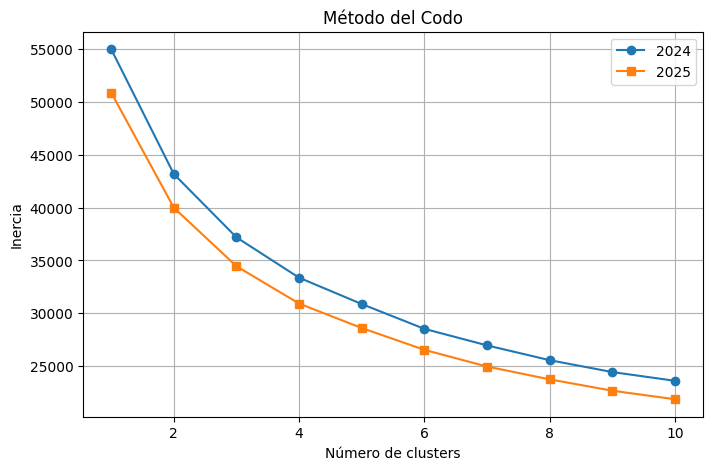

In [125]:
# ==========================================================
# MÉTODO DEL CODO
# ==========================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(1,11)

inercia24 = []
inercia25 = []

for k in k_values:

    modelo24 = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=20
    )

    modelo24.fit(X24)
    inercia24.append(modelo24.inertia_)

    modelo25 = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=20
    )

    modelo25.fit(X25)
    inercia25.append(modelo25.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_values,inercia24,'o-',label="2024")
plt.plot(k_values,inercia25,'s-',label="2025")

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.legend()
plt.grid(True)

plt.show()

In [126]:
# ==========================================================
# KMEANS DEFINITIVO
# ==========================================================

k = 3

kmeans24 = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=20
)

cluster24 = kmeans24.fit_predict(X24)

kmeans25 = KMeans(
    n_clusters=k,
    random_state=123,
    n_init=20
)

cluster25 = kmeans25.fit_predict(X25)

pca24["cluster"] = cluster24
pca25["cluster"] = cluster25

print("Distribución clusters 2024")
print(pca24.cluster.value_counts())

print("\nDistribución clusters 2025")
print(pca25.cluster.value_counts())

Distribución clusters 2024
cluster
0    2949
2    2688
1    2221
Name: count, dtype: int64

Distribución clusters 2025
cluster
1    2723
0    2423
2    2125
Name: count, dtype: int64


In [127]:
# ==========================================================
# PERFIL DE LOS CLUSTERS
# ==========================================================

print("===== Perfil de los clusters 2024 =====")

display(
    pca24.groupby("cluster")[variables_pca]
    .mean()
    .round(2)
)

print("\n===== Perfil de los clusters 2025 =====")

display(
    pca25.groupby("cluster")[variables_pca]
    .mean()
    .round(2)
)

===== Perfil de los clusters 2024 =====


,edad,edad2,educ,horastrab,nhogar,P21,PP04C
cluster,,,,,,,
0,35.46,1310.35,11.77,38.49,3.09,471831.06,3.97
1,58.54,3478.30,10.28,31.43,2.95,429276.86,3.09
2,44.56,2069.58,14.45,43.54,2.76,1210857.43,8.83



===== Perfil de los clusters 2025 =====


,edad,edad2,educ,horastrab,nhogar,P21,PP04C
cluster,,,,,,,
0,46.49,2236.81,14.47,43.95,2.85,1700558.81,8.52
1,35.25,1292.78,12.12,38.38,2.92,724272.05,4.10
2,58.51,3482.78,9.74,32.89,3.01,619272.35,2.89


Codigo para el inciso 4.a

In [128]:
k = 2

kmeans24 = KMeans(
    n_clusters=2,
    random_state=123,
    n_init=20
)

cluster24 = kmeans24.fit_predict(X24)

kmeans25 = KMeans(
    n_clusters=2,
    random_state=123,
    n_init=20
)

cluster25 = kmeans25.fit_predict(X25)

pca24["cluster2"] = cluster24
pca25["cluster2"] = cluster25

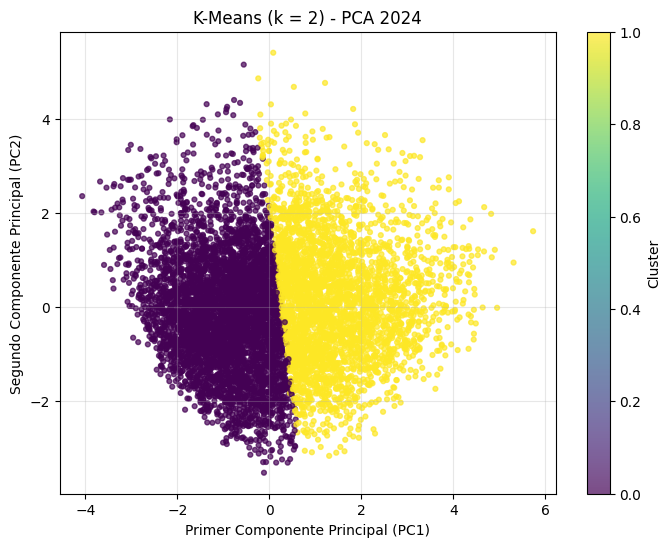

In [129]:
# ==========================================================
# K-MEANS (k = 2) SOBRE LOS DOS PRIMEROS COMPONENTES
# 2024
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    scores24[:,0],
    scores24[:,1],
    c=pca24["cluster2"],
    cmap="viridis",
    s=12,
    alpha=0.7
)

plt.xlabel("Primer Componente Principal (PC1)")
plt.ylabel("Segundo Componente Principal (PC2)")
plt.title("K-Means (k = 2) - PCA 2024")

plt.colorbar(label="Cluster")

plt.grid(alpha=0.3)

plt.show()

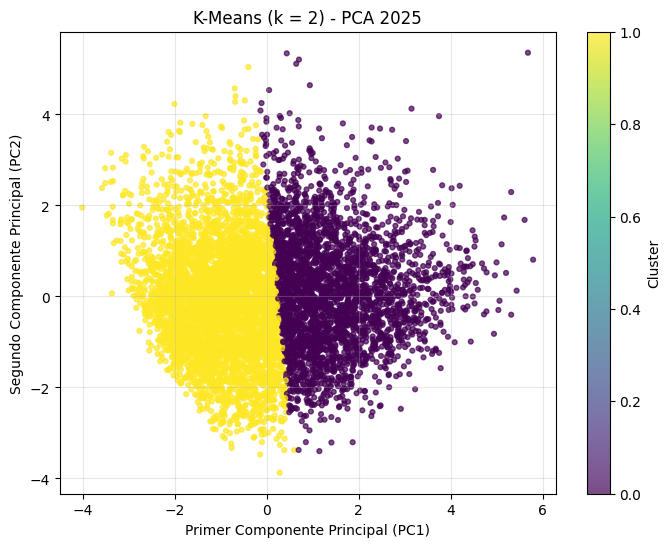

In [130]:
# ==========================================================
# K-MEANS (k = 2) SOBRE LOS DOS PRIMEROS COMPONENTES
# 2025
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    scores25[:,0],
    scores25[:,1],
    c=pca25["cluster2"],
    cmap="viridis",
    s=12,
    alpha=0.7
)

plt.xlabel("Primer Componente Principal (PC1)")
plt.ylabel("Segundo Componente Principal (PC2)")
plt.title("K-Means (k = 2) - PCA 2025")

plt.colorbar(label="Cluster")

plt.grid(alpha=0.3)

plt.show()

¿Puede el algoritmo separar correctamente a las personas informales y formales?

In [131]:
print("===== FORMAL / INFORMAL POR CLUSTER - 2024 =====")

tabla24 = (
    ocupados24.loc[pca24.index]
    .assign(cluster=pca24["cluster2"])
    .groupby("cluster")[["formal", "informal"]]
    .mean()
)

display(tabla24.round(3))

===== FORMAL / INFORMAL POR CLUSTER - 2024 =====


,formal,informal
cluster,,
0,0.615,0.087
1,0.331,0.048


In [132]:
print("===== FORMAL / INFORMAL POR CLUSTER - 2025 =====")

tabla25 = (
    ocupados25.loc[pca25.index]
    .assign(cluster=pca25["cluster2"])
    .groupby("cluster")[["formal", "informal"]]
    .mean()
)

display(tabla25.round(3))

===== FORMAL / INFORMAL POR CLUSTER - 2025 =====


,formal,informal
cluster,,
0,0.316,0.052
1,0.594,0.089


Clustering jerarquico

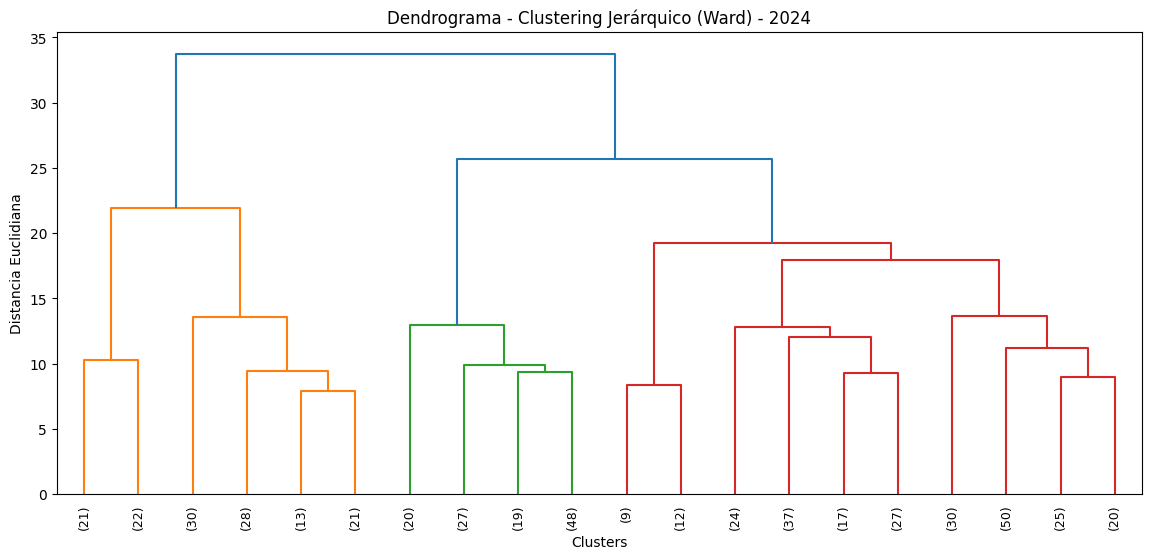

In [133]:
# ==========================================================
# CLUSTERING JERÁRQUICO - 2024
# ==========================================================

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

muestra24 = pca24.sample(n=500, random_state=123)

X_h24 = StandardScaler().fit_transform(
    muestra24[variables_pca]
)

Z24 = linkage(X_h24, method="ward")

plt.figure(figsize=(14,6))

dendrogram(
    Z24,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Dendrograma - Clustering Jerárquico (Ward) - 2024")
plt.xlabel("Clusters")
plt.ylabel("Distancia Euclidiana")

plt.show()

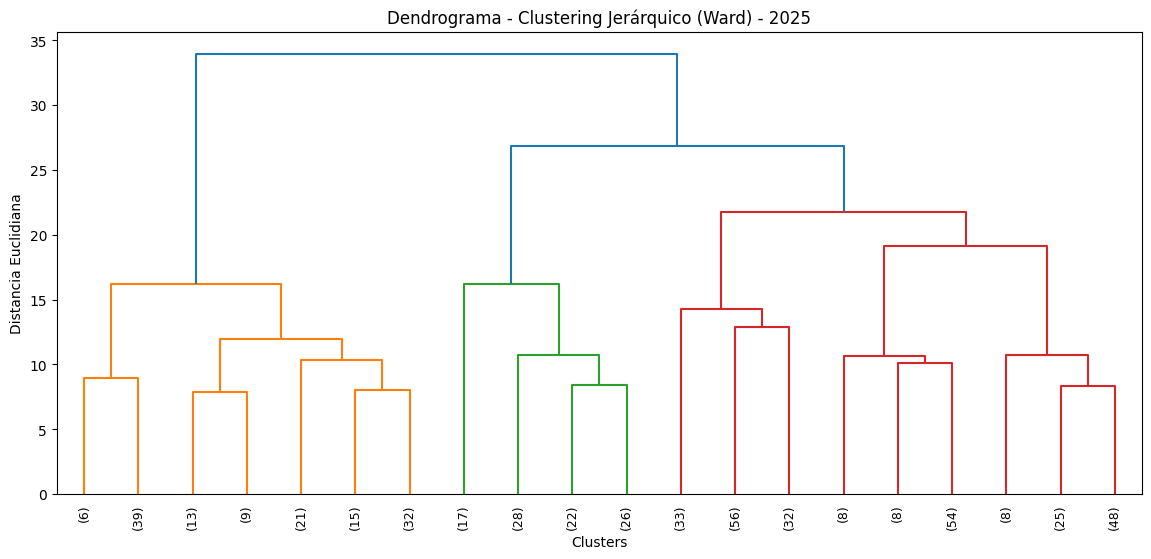

In [134]:
# ==========================================================
# CLUSTERING JERÁRQUICO - 2025
# ==========================================================

muestra25 = pca25.sample(n=500, random_state=123)

X_h25 = StandardScaler().fit_transform(
    muestra25[variables_pca]
)

Z25 = linkage(X_h25, method="ward")

plt.figure(figsize=(14,6))

dendrogram(
    Z25,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Dendrograma - Clustering Jerárquico (Ward) - 2025")
plt.xlabel("Clusters")
plt.ylabel("Distancia Euclidiana")

plt.show()

K-Modes

In [135]:
!pip install kmodes

In [136]:
from kmodes.kmodes import KModes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [137]:
# =====================================================
# BASE CATEGÓRICA PARA K-MODES
# =====================================================

km24 = ocupados24.loc[pca24.index].copy()
km25 = ocupados25.loc[pca25.index].copy()

In [138]:
# =====================================================
# CATEGORIZACIÓN
# =====================================================

for df in [km24, km25]:

    # Edad
    df["edad_cat"] = pd.cut(
        df["edad"],
        bins=[0,30,45,60,120],
        labels=["18-29","30-44","45-59","60+"]
    )

    # Educación
    df["educ_cat"] = pd.cut(
        df["educ"],
        bins=[-1,8,12,16,30],
        labels=["Baja","Media","Alta","Superior"]
    )

    # Horas
    df["horas_cat"] = pd.cut(
        df["horastrab"],
        bins=[-1,30,45,100],
        labels=["<=30","31-45",">45"]
    )

    # Tamaño hogar
    df["hogar_cat"] = pd.cut(
        df["nhogar"],
        bins=[0,2,4,20],
        labels=["1-2","3-4","5+"]
    )

    # Ingreso por cuartiles
    df["ingreso_cat"] = pd.qcut(
        df["P21"],
        q=4,
        labels=["Q1","Q2","Q3","Q4"]
    )

    # PP04C ya es categórica
    df["empresa_cat"] = df["PP04C"].astype(str)

In [139]:
variables_kmodes = [

    "mujer",
    "casado",
    "universitario",
    "asalariado",
    "formal",

    "edad_cat",
    "educ_cat",
    "horas_cat",
    "hogar_cat",
    "ingreso_cat",
    "empresa_cat"

]

In [140]:
Xkm24 = km24[variables_kmodes].astype(str)

Xkm25 = km25[variables_kmodes].astype(str)

In [141]:
modelo24 = KModes(

    n_clusters=2,
    init="Huang",
    random_state=123

)

cluster24 = modelo24.fit_predict(Xkm24)

modelo25 = KModes(

    n_clusters=2,
    init="Huang",
    random_state=123

)

cluster25 = modelo25.fit_predict(Xkm25)

km24["cluster"] = cluster24
km25["cluster"] = cluster25

In [142]:
print("2024")

print(km24.cluster.value_counts())

print()

print("2025")

print(km25.cluster.value_counts())

2024
cluster
0    4727
1    3131
Name: count, dtype: int64

2025
cluster
0    4314
1    2957
Name: count, dtype: int64


¿Puede el algoritmo k-modas con k = 2 separar correctamente a las personas informales y formales?

In [143]:
print("===== KMODES 2024 =====")

tabla_km24 = (
    km24
    .groupby("cluster")[["formal","informal"]]
    .mean()
)

display(tabla_km24.round(3))

===== KMODES 2024 =====


,formal,informal
cluster,,
0,0.741,0.063
1,0.141,0.084


In [144]:
print("===== KMODES 2025 =====")

tabla_km25 = (
    km25
    .groupby("cluster")[["formal","informal"]]
    .mean()
)

display(tabla_km25.round(3))

===== KMODES 2025 =====


,formal,informal
cluster,,
0,0.722,0.067
1,0.130,0.084


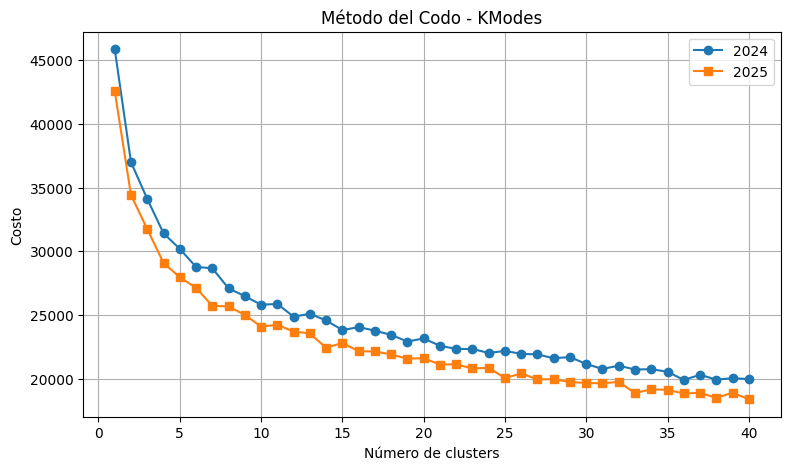

In [145]:
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

costos24 = []
costos25 = []

K = range(1,41)

for k in K:

    modelo24 = KModes(
        n_clusters=k,
        init="Huang",
        random_state=123
    )

    modelo24.fit(Xkm24)

    costos24.append(modelo24.cost_)

    modelo25 = KModes(
        n_clusters=k,
        init="Huang",
        random_state=123
    )

    modelo25.fit(Xkm25)

    costos25.append(modelo25.cost_)

plt.figure(figsize=(9,5))

plt.plot(K,costos24,'o-',label="2024")
plt.plot(K,costos25,'s-',label="2025")

plt.xlabel("Número de clusters")
plt.ylabel("Costo")
plt.title("Método del Codo - KModes")

plt.grid(True)
plt.legend()

plt.show()

# Parte II.B.6 - Clustering mediante K-Modas

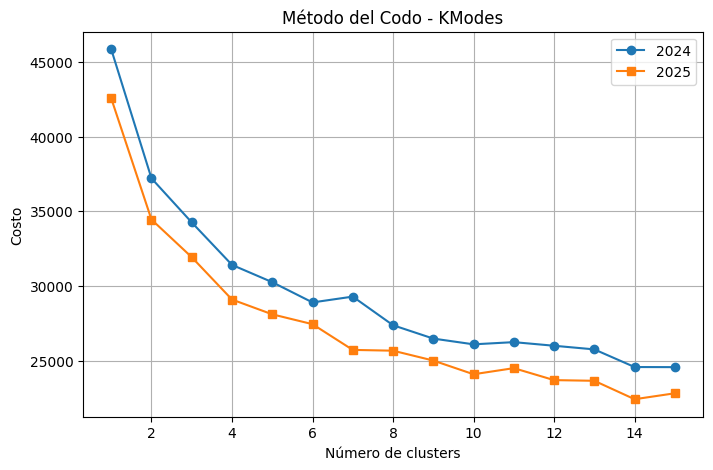

In [146]:
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

costos24 = []
costos25 = []

K = range(1,16)

for k in K:

    modelo24 = KModes(
        n_clusters=k,
        init="Huang",
        random_state=123,
        n_init=5
    )

    modelo24.fit(Xkm24)

    costos24.append(modelo24.cost_)

    modelo25 = KModes(
        n_clusters=k,
        init="Huang",
        random_state=123,
        n_init=5
    )

    modelo25.fit(Xkm25)

    costos25.append(modelo25.cost_)

plt.figure(figsize=(8,5))

plt.plot(K,costos24,'o-',label="2024")
plt.plot(K,costos25,'s-',label="2025")

plt.grid(True)
plt.legend()

plt.xlabel("Número de clusters")

plt.ylabel("Costo")

plt.title("Método del Codo - KModes")

plt.show()

Pantallas de salida

In [147]:
import os

os.makedirs("resultados_tp2", exist_ok=True)
os.makedirs("resultados_tp2/figuras", exist_ok=True)
os.makedirs("resultados_tp2/tablas", exist_ok=True)

print("Carpetas creadas correctamente.")

Carpetas creadas correctamente.


Exportar tablas de PCA a Excel

In [148]:
# Perfiles de K-Means con k = 3
perfil_kmeans24 = (
    pca24.groupby("cluster")[variables_pca]
    .mean()
    .round(2)
)

perfil_kmeans25 = (
    pca25.groupby("cluster")[variables_pca]
    .mean()
    .round(2)
)

# Comparación K-Means k = 2 con formalidad e informalidad
tabla_kmeans24 = (
    ocupados24.loc[pca24.index]
    .assign(cluster=pca24["cluster2"])
    .groupby("cluster")[["formal", "informal"]]
    .mean()
    .round(3)
)

tabla_kmeans25 = (
    ocupados25.loc[pca25.index]
    .assign(cluster=pca25["cluster2"])
    .groupby("cluster")[["formal", "informal"]]
    .mean()
    .round(3)
)

# Comparación K-Modes con formalidad e informalidad
tabla_kmodes24 = (
    km24.groupby("cluster")[["formal", "informal"]]
    .mean()
    .round(3)
)

tabla_kmodes25 = (
    km25.groupby("cluster")[["formal", "informal"]]
    .mean()
    .round(3)
)

# Exportar todo a un solo Excel
ruta_excel = "resultados_tp2/tablas/Tablas_Resultados_TP2.xlsx"

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    var24.round(4).to_excel(
        writer, sheet_name="Varianza_PCA_2024", index=False
    )
    var25.round(4).to_excel(
        writer, sheet_name="Varianza_PCA_2025", index=False
    )
    loadings24.round(3).to_excel(
        writer, sheet_name="Loadings_2024"
    )
    loadings25.round(3).to_excel(
        writer, sheet_name="Loadings_2025"
    )
    perfil_kmeans24.to_excel(
        writer, sheet_name="Perfil_KMeans_2024"
    )
    perfil_kmeans25.to_excel(
        writer, sheet_name="Perfil_KMeans_2025"
    )
    tabla_kmeans24.to_excel(
        writer, sheet_name="KMeans_Formal_2024"
    )
    tabla_kmeans25.to_excel(
        writer, sheet_name="KMeans_Formal_2025"
    )
    tabla_kmodes24.to_excel(
        writer, sheet_name="KModes_Formal_2024"
    )
    tabla_kmodes25.to_excel(
        writer, sheet_name="KModes_Formal_2025"
    )

print("Excel creado:", ruta_excel)

Excel creado: resultados_tp2/tablas/Tablas_Resultados_TP2.xlsx


Guardar tabla descriptiva

In [149]:
descriptivos24 = (
    ocupados24[variables_pca + ["formal", "informal"]]
    .describe()
    .T
    .round(2)
)

descriptivos25 = (
    ocupados25[variables_pca + ["formal", "informal"]]
    .describe()
    .T
    .round(2)
)

ruta_descriptivos = "resultados_tp2/tablas/Tablas_Descriptivas_TP2.xlsx"

with pd.ExcelWriter(ruta_descriptivos, engine="openpyxl") as writer:
    descriptivos24.to_excel(
        writer, sheet_name="Descriptivos_2024"
    )
    descriptivos25.to_excel(
        writer, sheet_name="Descriptivos_2025"
    )
    corr24.round(3).to_excel(
        writer, sheet_name="Correlaciones_2024"
    )
    corr25.round(3).to_excel(
        writer, sheet_name="Correlaciones_2025"
    )

print("Descriptivos exportados:", ruta_descriptivos)

Descriptivos exportados: resultados_tp2/tablas/Tablas_Descriptivas_TP2.xlsx


Guardar método del codo de K-Means

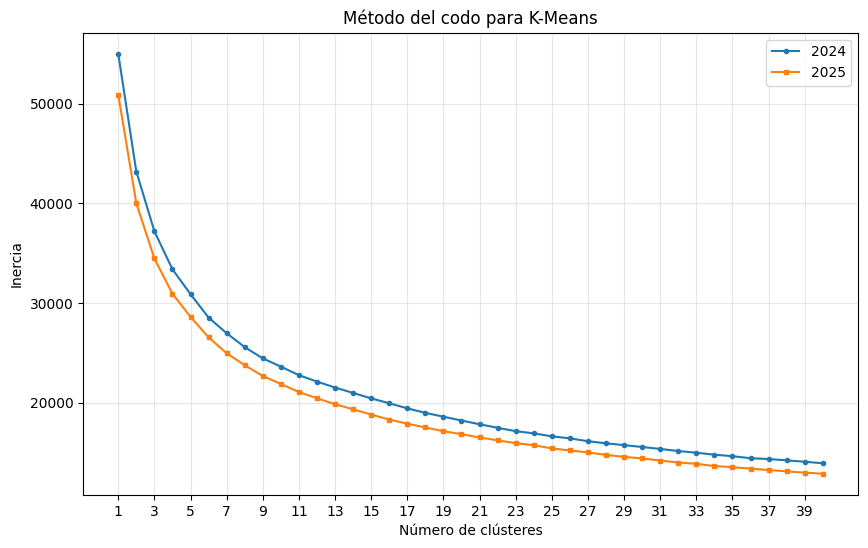

In [150]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

K_kmeans = range(1, 41)
inercia24_final = []
inercia25_final = []

for k in K_kmeans:
    modelo24 = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=20
    )
    modelo24.fit(X24)
    inercia24_final.append(modelo24.inertia_)

    modelo25 = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=20
    )
    modelo25.fit(X25)
    inercia25_final.append(modelo25.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    list(K_kmeans),
    inercia24_final,
    marker="o",
    markersize=3,
    label="2024"
)

plt.plot(
    list(K_kmeans),
    inercia25_final,
    marker="s",
    markersize=3,
    label="2025"
)

plt.xlabel("Número de clústeres")
plt.ylabel("Inercia")
plt.title("Método del codo para K-Means")
plt.xticks(range(1, 41, 2))
plt.grid(alpha=0.3)
plt.legend()

plt.savefig(
    "resultados_tp2/figuras/Figura_01_Codo_KMeans.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardar K-Means k=2, PCA 2024

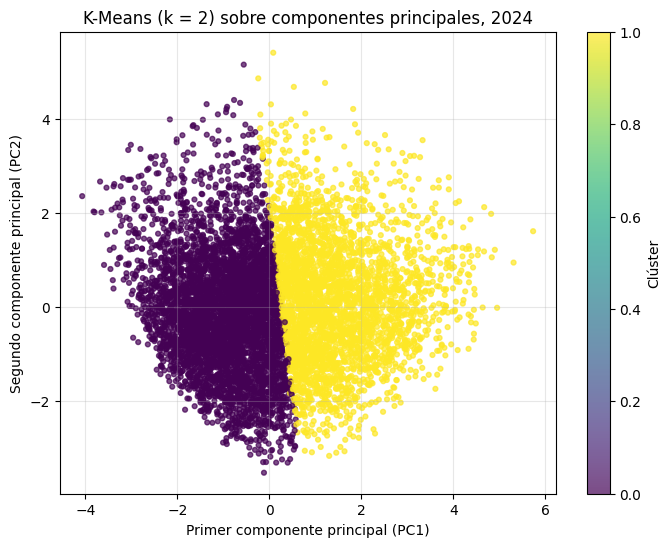

In [151]:
plt.figure(figsize=(8, 6))

grafico = plt.scatter(
    scores24[:, 0],
    scores24[:, 1],
    c=pca24["cluster2"],
    cmap="viridis",
    s=12,
    alpha=0.7
)

plt.xlabel("Primer componente principal (PC1)")
plt.ylabel("Segundo componente principal (PC2)")
plt.title("K-Means (k = 2) sobre componentes principales, 2024")
plt.colorbar(grafico, label="Clúster")
plt.grid(alpha=0.3)

plt.savefig(
    "resultados_tp2/figuras/Figura_02_KMeans_PCA_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardar K-Means k=2, PCA 2025

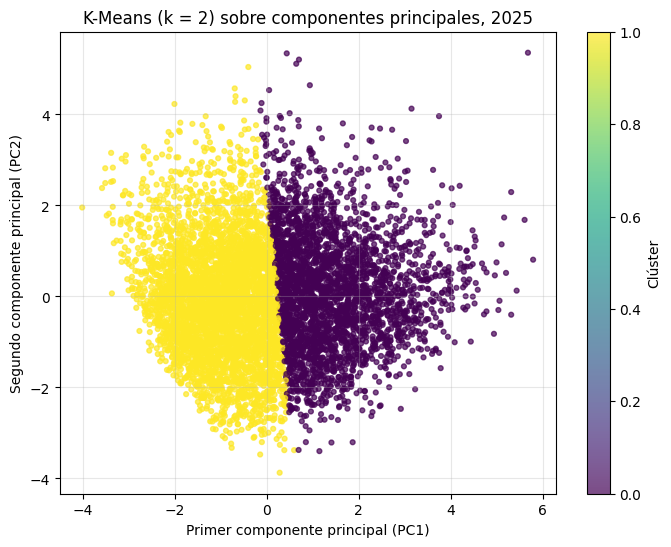

In [152]:
plt.figure(figsize=(8, 6))

grafico = plt.scatter(
    scores25[:, 0],
    scores25[:, 1],
    c=pca25["cluster2"],
    cmap="viridis",
    s=12,
    alpha=0.7
)

plt.xlabel("Primer componente principal (PC1)")
plt.ylabel("Segundo componente principal (PC2)")
plt.title("K-Means (k = 2) sobre componentes principales, 2025")
plt.colorbar(grafico, label="Clúster")
plt.grid(alpha=0.3)

plt.savefig(
    "resultados_tp2/figuras/Figura_03_KMeans_PCA_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardar dendrograma 2024

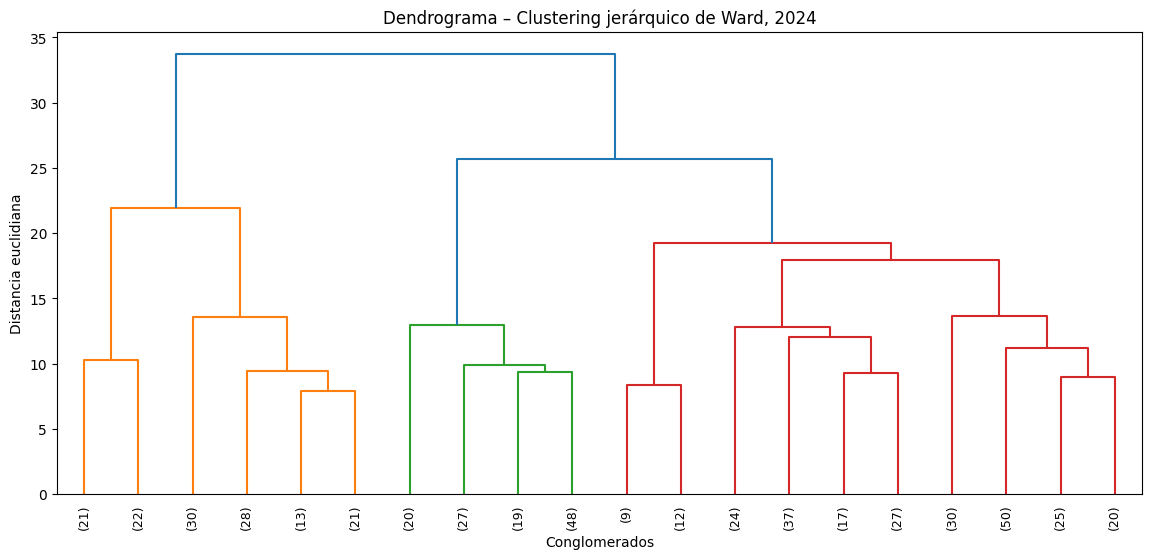

In [153]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(14, 6))

dendrogram(
    Z24,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Dendrograma – Clustering jerárquico de Ward, 2024")
plt.xlabel("Conglomerados")
plt.ylabel("Distancia euclidiana")

plt.savefig(
    "resultados_tp2/figuras/Figura_04_Dendrograma_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardar dendrograma 2025

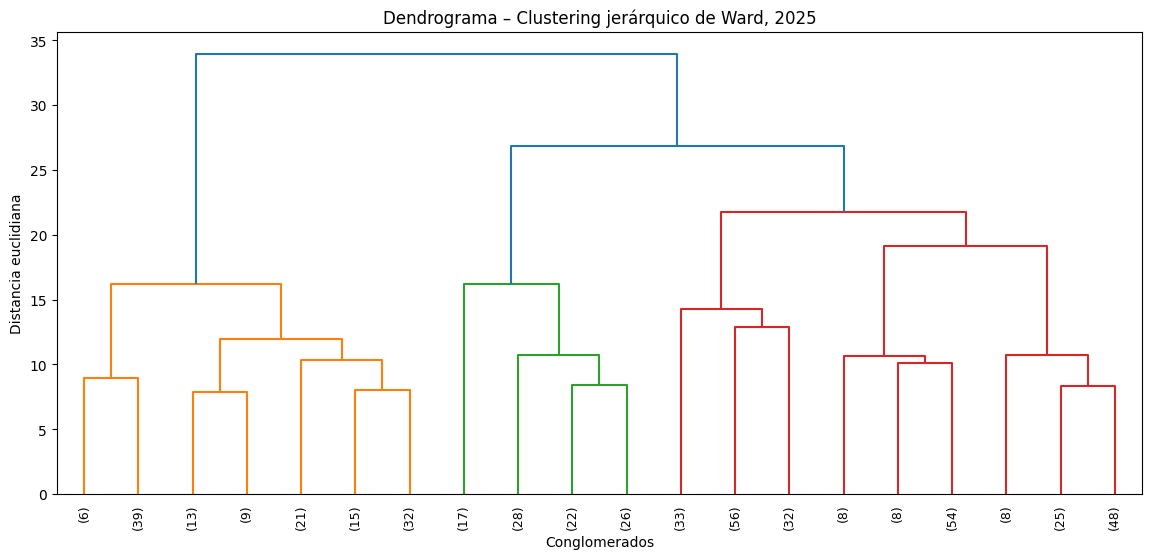

In [154]:
plt.figure(figsize=(14, 6))

dendrogram(
    Z25,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Dendrograma – Clustering jerárquico de Ward, 2025")
plt.xlabel("Conglomerados")
plt.ylabel("Distancia euclidiana")

plt.savefig(
    "resultados_tp2/figuras/Figura_05_Dendrograma_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Guardar método del codo de K-Modes

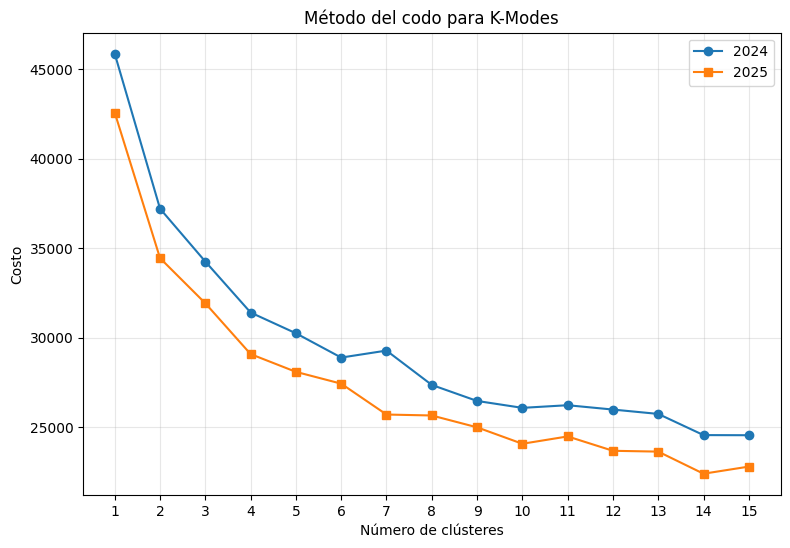

In [155]:
plt.figure(figsize=(9, 6))

plt.plot(
    list(K),
    costos24,
    marker="o",
    label="2024"
)

plt.plot(
    list(K),
    costos25,
    marker="s",
    label="2025"
)

plt.xlabel("Número de clústeres")
plt.ylabel("Costo")
plt.title("Método del codo para K-Modes")
plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.legend()

plt.savefig(
    "resultados_tp2/figuras/Figura_06_Codo_KModes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Exportar tablas también como CSV

In [156]:
var24.round(4).to_csv(
    "resultados_tp2/tablas/Varianza_PCA_2024.csv",
    index=False
)

var25.round(4).to_csv(
    "resultados_tp2/tablas/Varianza_PCA_2025.csv",
    index=False
)

loadings24.round(3).to_csv(
    "resultados_tp2/tablas/Loadings_PCA_2024.csv"
)

loadings25.round(3).to_csv(
    "resultados_tp2/tablas/Loadings_PCA_2025.csv"
)

perfil_kmeans24.to_csv(
    "resultados_tp2/tablas/Perfil_KMeans_2024.csv"
)

perfil_kmeans25.to_csv(
    "resultados_tp2/tablas/Perfil_KMeans_2025.csv"
)

tabla_kmeans24.to_csv(
    "resultados_tp2/tablas/KMeans_Formal_Informal_2024.csv"
)

tabla_kmeans25.to_csv(
    "resultados_tp2/tablas/KMeans_Formal_Informal_2025.csv"
)

tabla_kmodes24.to_csv(
    "resultados_tp2/tablas/KModes_Formal_Informal_2024.csv"
)

tabla_kmodes25.to_csv(
    "resultados_tp2/tablas/KModes_Formal_Informal_2025.csv"
)

print("Archivos CSV creados correctamente.")

Archivos CSV creados correctamente.


Verificar que todos los archivos existen

In [157]:
import glob

archivos = sorted(
    glob.glob("resultados_tp2/**/*", recursive=True)
)

for archivo in archivos:
    if os.path.isfile(archivo):
        print(archivo)

resultados_tp2/figuras/Figura_01_Codo_KMeans.png
resultados_tp2/figuras/Figura_02_KMeans_PCA_2024.png
resultados_tp2/figuras/Figura_03_KMeans_PCA_2025.png
resultados_tp2/figuras/Figura_04_Dendrograma_2024.png
resultados_tp2/figuras/Figura_05_Dendrograma_2025.png
resultados_tp2/figuras/Figura_06_Codo_KModes.png
resultados_tp2/tablas/KMeans_Formal_Informal_2024.csv
resultados_tp2/tablas/KMeans_Formal_Informal_2025.csv
resultados_tp2/tablas/KModes_Formal_Informal_2024.csv
resultados_tp2/tablas/KModes_Formal_Informal_2025.csv
resultados_tp2/tablas/Loadings_PCA_2024.csv
resultados_tp2/tablas/Loadings_PCA_2025.csv
resultados_tp2/tablas/Perfil_KMeans_2024.csv
resultados_tp2/tablas/Perfil_KMeans_2025.csv
resultados_tp2/tablas/Tablas_Descriptivas_TP2.xlsx
resultados_tp2/tablas/Tablas_Resultados_TP2.xlsx
resultados_tp2/tablas/Varianza_PCA_2024.csv
resultados_tp2/tablas/Varianza_PCA_2025.csv


Comprimir todo en un ZIP

In [158]:
import shutil

shutil.make_archive(
    "Resultados_TP2_Grupo2",
    "zip",
    "resultados_tp2"
)

print("ZIP creado: Resultados_TP2_Grupo2.zip")

ZIP creado: Resultados_TP2_Grupo2.zip


In [159]:
from google.colab import files

files.download("Resultados_TP2_Grupo2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Creacion carpeta de figuras

In [160]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("resultados_tp2/figuras", exist_ok=True)

print("Carpeta de figuras preparada.")

Carpeta de figuras preparada.


Preparar las categorias formal e informal

In [161]:
# Formalidad correspondiente a las mismas observaciones utilizadas en PCA

condicion24 = ocupados24.loc[pca24.index, ["formal", "informal"]].copy()
condicion25 = ocupados25.loc[pca25.index, ["formal", "informal"]].copy()

condicion24["condicion"] = np.select(
    [
        condicion24["formal"] == 1,
        condicion24["informal"] == 1
    ],
    [
        "Formal",
        "Informal"
    ],
    default="Otra condición"
)

condicion25["condicion"] = np.select(
    [
        condicion25["formal"] == 1,
        condicion25["informal"] == 1
    ],
    [
        "Formal",
        "Informal"
    ],
    default="Otra condición"
)

print(condicion24["condicion"].value_counts())
print()
print(condicion25["condicion"].value_counts())

condicion
Formal            3941
Otra condición    3359
Informal           558
Name: count, dtype: int64

condicion
Formal            3497
Otra condición    3237
Informal           537
Name: count, dtype: int64


Gráfico de scores PCA 2024

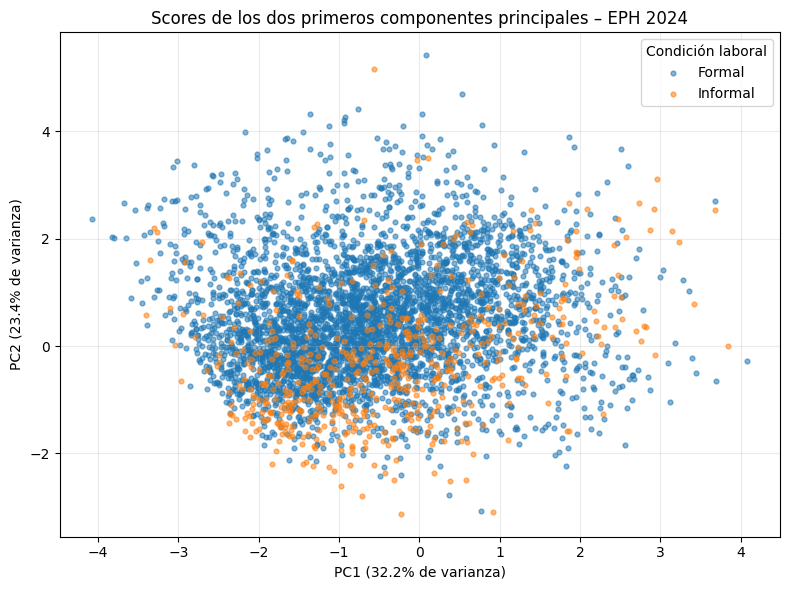

In [162]:
# ==========================================================
# SCORES PCA 2024: FORMAL VS. INFORMAL
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 6))

for grupo in ["Formal", "Informal"]:
    mascara = condicion24["condicion"].to_numpy() == grupo

    ax.scatter(
        scores24[mascara, 0],
        scores24[mascara, 1],
        s=12,
        alpha=0.55,
        label=grupo
    )

ax.set_xlabel(
    f"PC1 ({pca_model24.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)
ax.set_ylabel(
    f"PC2 ({pca_model24.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)
ax.set_title(
    "Scores de los dos primeros componentes principales – EPH 2024"
)
ax.grid(alpha=0.25)
ax.legend(title="Condición laboral")

fig.tight_layout()

fig.savefig(
    "resultados_tp2/figuras/Figura_07_Scores_PCA_Formal_Informal_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Gráfico de scores PCA 2025

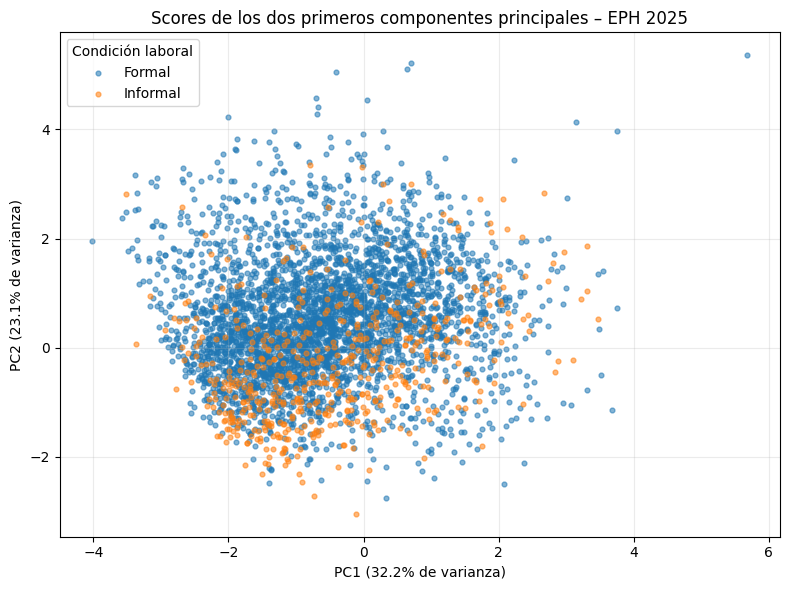

In [163]:
# ==========================================================
# SCORES PCA 2025: FORMAL VS. INFORMAL
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 6))

for grupo in ["Formal", "Informal"]:
    mascara = condicion25["condicion"].to_numpy() == grupo

    ax.scatter(
        scores25[mascara, 0],
        scores25[mascara, 1],
        s=12,
        alpha=0.55,
        label=grupo
    )

ax.set_xlabel(
    f"PC1 ({pca_model25.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)
ax.set_ylabel(
    f"PC2 ({pca_model25.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)
ax.set_title(
    "Scores de los dos primeros componentes principales – EPH 2025"
)
ax.grid(alpha=0.25)
ax.legend(title="Condición laboral")

fig.tight_layout()

fig.savefig(
    "resultados_tp2/figuras/Figura_08_Scores_PCA_Formal_Informal_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Biplot PCA 2024: scores y flechas de loadings

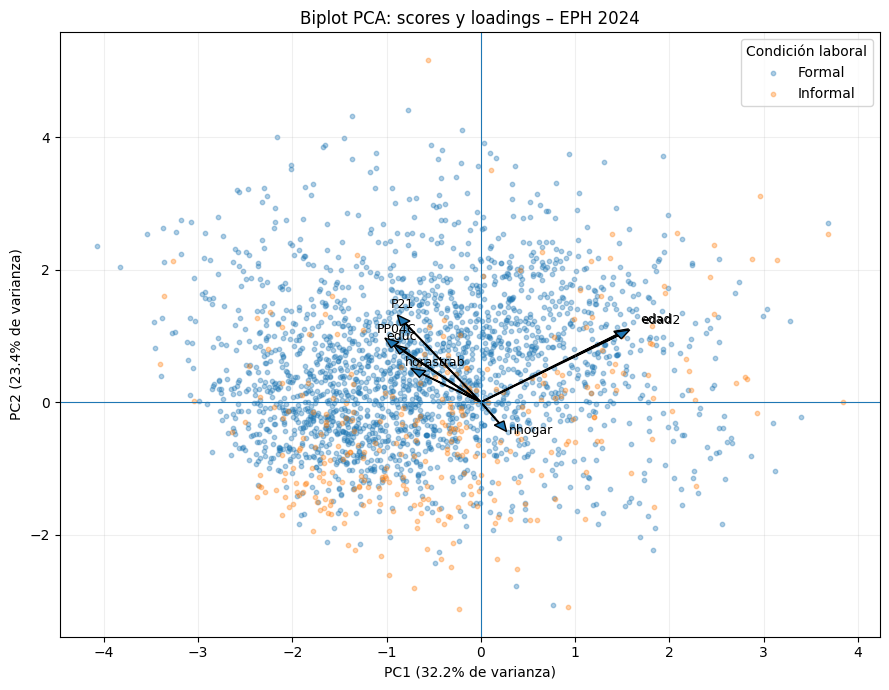

In [164]:
# ==========================================================
# BIPLOT PCA 2024
# ==========================================================

rng = np.random.default_rng(123)

indices_validos24 = np.where(
    condicion24["condicion"].isin(["Formal", "Informal"]).to_numpy()
)[0]

n_muestra24 = min(2500, len(indices_validos24))

indices_grafico24 = rng.choice(
    indices_validos24,
    size=n_muestra24,
    replace=False
)

fig, ax = plt.subplots(figsize=(9, 7))

for grupo in ["Formal", "Informal"]:
    mascara = (
        condicion24.iloc[indices_grafico24]["condicion"].to_numpy()
        == grupo
    )

    posiciones = indices_grafico24[mascara]

    ax.scatter(
        scores24[posiciones, 0],
        scores24[posiciones, 1],
        s=10,
        alpha=0.35,
        label=grupo
    )

# Escala para que las flechas sean visibles sobre los scores
escala_x24 = np.percentile(np.abs(scores24[:, 0]), 95)
escala_y24 = np.percentile(np.abs(scores24[:, 1]), 95)

for variable in variables_pca:
    carga_pc1 = loadings24.loc[variable, "PC1"]
    carga_pc2 = loadings24.loc[variable, "PC2"]

    x_fin = carga_pc1 * escala_x24
    y_fin = carga_pc2 * escala_y24

    ax.arrow(
        0,
        0,
        x_fin,
        y_fin,
        width=0.008,
        head_width=0.12,
        head_length=0.15,
        length_includes_head=True
    )

    ax.text(
        x_fin * 1.08,
        y_fin * 1.08,
        variable,
        fontsize=9
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel(
    f"PC1 ({pca_model24.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)
ax.set_ylabel(
    f"PC2 ({pca_model24.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)
ax.set_title(
    "Biplot PCA: scores y loadings – EPH 2024"
)
ax.grid(alpha=0.2)
ax.legend(title="Condición laboral")

fig.tight_layout()

fig.savefig(
    "resultados_tp2/figuras/Figura_09_Biplot_PCA_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Biplot PCA 2025

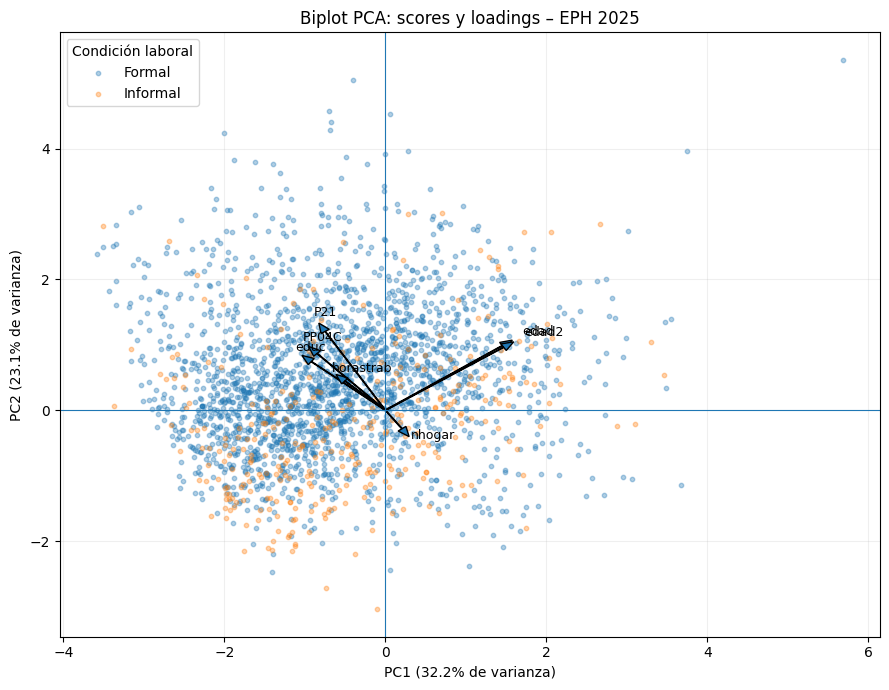

In [165]:
# ==========================================================
# BIPLOT PCA 2025
# ==========================================================

rng = np.random.default_rng(123)

indices_validos25 = np.where(
    condicion25["condicion"].isin(["Formal", "Informal"]).to_numpy()
)[0]

n_muestra25 = min(2500, len(indices_validos25))

indices_grafico25 = rng.choice(
    indices_validos25,
    size=n_muestra25,
    replace=False
)

fig, ax = plt.subplots(figsize=(9, 7))

for grupo in ["Formal", "Informal"]:
    mascara = (
        condicion25.iloc[indices_grafico25]["condicion"].to_numpy()
        == grupo
    )

    posiciones = indices_grafico25[mascara]

    ax.scatter(
        scores25[posiciones, 0],
        scores25[posiciones, 1],
        s=10,
        alpha=0.35,
        label=grupo
    )

escala_x25 = np.percentile(np.abs(scores25[:, 0]), 95)
escala_y25 = np.percentile(np.abs(scores25[:, 1]), 95)

for variable in variables_pca:
    carga_pc1 = loadings25.loc[variable, "PC1"]
    carga_pc2 = loadings25.loc[variable, "PC2"]

    x_fin = carga_pc1 * escala_x25
    y_fin = carga_pc2 * escala_y25

    ax.arrow(
        0,
        0,
        x_fin,
        y_fin,
        width=0.008,
        head_width=0.12,
        head_length=0.15,
        length_includes_head=True
    )

    ax.text(
        x_fin * 1.08,
        y_fin * 1.08,
        variable,
        fontsize=9
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel(
    f"PC1 ({pca_model25.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)
ax.set_ylabel(
    f"PC2 ({pca_model25.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)
ax.set_title(
    "Biplot PCA: scores y loadings – EPH 2025"
)
ax.grid(alpha=0.2)
ax.legend(title="Condición laboral")

fig.tight_layout()

fig.savefig(
    "resultados_tp2/figuras/Figura_10_Biplot_PCA_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Gráfico de proporción de varianza explicada

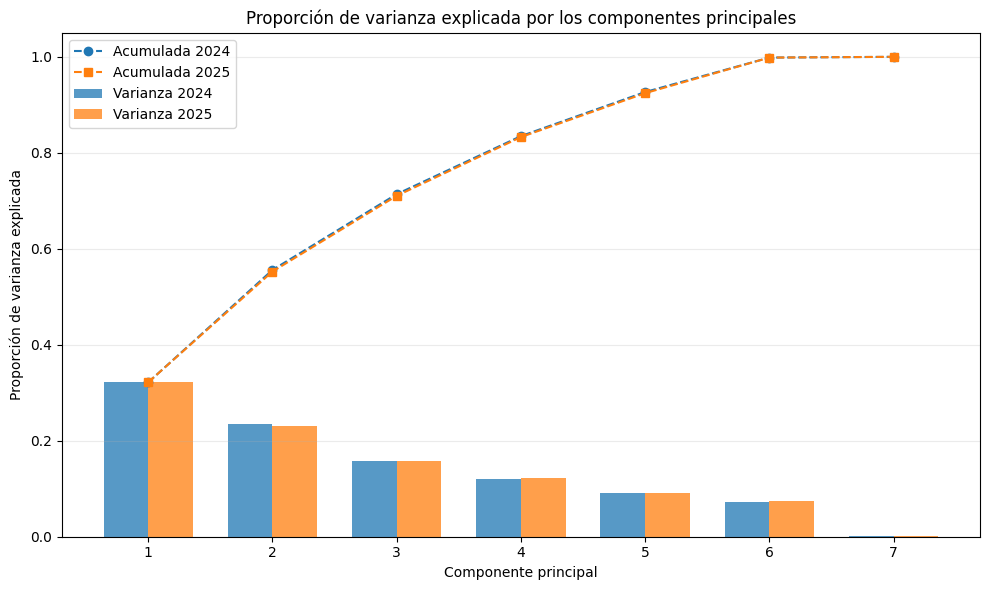

In [166]:
# ==========================================================
# VARIANZA EXPLICADA PCA 2024–2025
# ==========================================================

componentes = np.arange(1, len(variables_pca) + 1)

var_exp24 = pca_model24.explained_variance_ratio_
var_exp25 = pca_model25.explained_variance_ratio_

var_acum24 = np.cumsum(var_exp24)
var_acum25 = np.cumsum(var_exp25)

ancho = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    componentes - ancho / 2,
    var_exp24,
    width=ancho,
    alpha=0.75,
    label="Varianza 2024"
)

ax.bar(
    componentes + ancho / 2,
    var_exp25,
    width=ancho,
    alpha=0.75,
    label="Varianza 2025"
)

ax.plot(
    componentes,
    var_acum24,
    marker="o",
    linestyle="--",
    label="Acumulada 2024"
)

ax.plot(
    componentes,
    var_acum25,
    marker="s",
    linestyle="--",
    label="Acumulada 2025"
)

ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de varianza explicada")
ax.set_title(
    "Proporción de varianza explicada por los componentes principales"
)
ax.set_xticks(componentes)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    "resultados_tp2/figuras/Figura_11_Varianza_Explicada_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Verificar que se guardaron

In [167]:
import glob

nuevas_figuras = sorted(
    glob.glob("resultados_tp2/figuras/Figura_0[7-9]*.png")
    + glob.glob("resultados_tp2/figuras/Figura_10*.png")
    + glob.glob("resultados_tp2/figuras/Figura_11*.png")
)

for archivo in nuevas_figuras:
    print(archivo)

resultados_tp2/figuras/Figura_07_Scores_PCA_Formal_Informal_2024.png
resultados_tp2/figuras/Figura_08_Scores_PCA_Formal_Informal_2025.png
resultados_tp2/figuras/Figura_09_Biplot_PCA_2024.png
resultados_tp2/figuras/Figura_10_Biplot_PCA_2025.png
resultados_tp2/figuras/Figura_11_Varianza_Explicada_PCA.png


Comprimir las nuevas figuras

In [168]:
import zipfile

archivo_zip = "Graficos_PCA_TP2.zip"

with zipfile.ZipFile(
    archivo_zip,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for archivo in nuevas_figuras:
        zipf.write(
            archivo,
            arcname=os.path.basename(archivo)
        )

print("Archivo creado:", archivo_zip)

Archivo creado: Graficos_PCA_TP2.zip


In [169]:
from google.colab import files

files.download("Graficos_PCA_TP2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>